# Анализ лояльности пользователей Яндекс Афиши

В этом исследовании я изучаю, какие характеристики первого заказа и последующего поведения пользователя связаны с возвратом на платформу. Цель работы — выделить практические паттерны удержания, которые можно использовать в CRM-коммуникациях, сегментации аудитории и дальнейшем скоринге вероятности повторной покупки.

В работе использованы данные о заказах Яндекс Афиши: идентификаторы пользователей и заказов, дата и время покупки, выручка, количество билетов, тип события, сервис, регион и город. Отдельно подключён справочник с курсом тенге к рублю, чтобы привести выручку к единой валюте.

Исследование состоит из четырёх частей:

1. загрузка и подготовка данных;
2. построение пользовательского профиля;
3. анализ сегментов, заказов и временных паттернов;
4. итоговые выводы и рекомендации для удержания пользователей.


## 1. Загрузка данных

Сначала загружаю данные о заказах и формирую рабочую выборку. В анализ включаю только заказы с устройств `mobile` и `desktop`, а события типа `фильм` исключаю ещё на этапе SQL-запроса, чтобы сосредоточиться на целевых сценариях использования сервиса.


### Описание исходных данных

В основе анализа лежит таблица заказов `afisha.purchases`, которая объединяется со справочниками событий, городов и регионов. После объединения в рабочую выборку попадают следующие ключевые поля:

- `user_id` — уникальный идентификатор пользователя.
- `order_id` — уникальный идентификатор заказа.
- `device_type_canonical` — тип устройства, с которого оформлен заказ (`mobile` или `desktop`).
- `order_dt` — дата заказа в московском времени.
- `order_ts` — точное время заказа в московском времени.
- `currency_code` — валюта заказа (`rub` или `kzt`).
- `revenue` — выручка по заказу в исходной валюте.
- `tickets_count` — количество билетов в заказе.
- `days_since_prev` — число дней с предыдущего заказа этого же пользователя.
- `event_id` — идентификатор мероприятия.
- `event_name` — код или название мероприятия.
- `event_type_main` — основной тип мероприятия, например концерт, театр или спорт.
- `service_name` — сервис или витрина, через которую был оформлен заказ.
- `region_name` — регион проведения события.
- `city_name` — город проведения события.

Дополнительно в проекте используется справочник курса тенге к рублю, чтобы привести выручку к единой валюте и корректно сравнивать заказы между собой.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

warnings.filterwarnings(
    'ignore'
)

try:
    import phik
except ImportError:
    !pip install phik
    import phik


In [2]:
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME'),
}

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)


In [4]:
query = '''
-- Основной запрос
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    -- Расчет количества дней между текущим и предыдущим заказом
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_ts_msk, p.order_id)))::integer AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
LEFT JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE 
    -- Фильтрация по типу устройства (только mobile и desktop)
    p.device_type_canonical IN ('mobile', 'desktop')
    -- Исключаем фильмы
    AND (e.event_type_main != 'фильм' OR e.event_type_main IS NULL)
-- Сортировка по user_id
ORDER BY p.user_id, p.created_ts_msk, p.order_id;
''' 

In [5]:
if os.path.exists('afisha.csv'):
    df = pd.read_csv('afisha.csv')
else:
    if not all(db_config.values()):
        raise ValueError(
            'Для выгрузки из БД заполните переменные окружения '
            'DB_USER, DB_PASSWORD, DB_HOST, DB_PORT и DB_NAME.'
        )

    engine = create_engine(connection_string)
    df = pd.read_sql_query(query, con=engine)


In [6]:
df

,Unnamed: 0,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290607,290607,fffcd3dde79eb2c,mobile,368620,2024-10-27,2024-10-27 18:00:57,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290608,290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск
290609,290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка


### Первичный обзор данных

После загрузки проверяю объём выборки, типы данных и общее качество выгрузки. На этом шаге важно убедиться, что в таблице есть все поля, необходимые для расчёта пользовательских метрик и анализа возвратов.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             290611 non-null  int64  
 1   user_id                290611 non-null  object 
 2   device_type_canonical  290611 non-null  object 
 3   order_id               290611 non-null  int64  
 4   order_dt               290611 non-null  object 
 5   order_ts               290611 non-null  object 
 6   currency_code          290611 non-null  object 
 7   revenue                290611 non-null  float64
 8   tickets_count          290611 non-null  int64  
 9   days_since_prev        268678 non-null  float64
 10  event_id               290611 non-null  int64  
 11  event_name             290611 non-null  object 
 12  event_type_main        290611 non-null  object 
 13  service_name           290611 non-null  object 
 14  region_name            290611 non-nu

Исходная выгрузка содержит **290 611 строк** и **15 признаков**, а объём данных составляет около **33.3 МБ**. Структура набора данных выглядит корректной: все ключевые поля заказа заполнены, а пропуски ожидаемо сосредоточены только в `days_since_prev`. 

Выгрузка из SQL выглядит корректной и достаточно полной для дальнейшего анализа. В таблице есть идентификаторы пользователей и заказов, дата и время покупки, выручка, число билетов, а также признаки события, региона и сервиса. По составу полей данных достаточно и для предобработки, и для построения пользовательского профиля, и для анализа факторов возврата.

## 2. Подготовка данных

Перед исследованием привожу данные к аналитическому виду: конвертирую выручку в рубли, проверяю пропуски, нормализую категориальные признаки, анализирую распределения и отфильтровываю некорректные значения, которые могли бы исказить выводы.


In [8]:
try:
    tenge_rub = pd.read_csv('final_tickets_tenge_df.csv')
except:
    tenge_rub = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [9]:
tenge_rub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [10]:
tenge_rub['data'] = pd.to_datetime(tenge_rub['data'])

In [11]:
def revenue_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    
    elif row['currency_code'] == 'kzt':
        rate = tenge_rub.loc[tenge_rub['data'] == row['order_dt'], 'curs']

        if len(rate) == 0:
            return None
    
        return row['revenue'] / 100 * rate.iloc[0]
    
    else:
        return None

In [12]:
df['revenue_rub'] = df.apply(revenue_rub, axis = 1)

### Проверка качества данных

На этом этапе последовательно смотрю на пропуски, типы данных, категориальные признаки, дубликаты и распределения ключевых количественных показателей. Основной фокус — на `revenue_rub` и `tickets_count`, потому что именно они сильнее всего влияют на интерпретацию монетизации и поведения пользователей.


In [13]:
df.isna().sum()

Unnamed: 0                   0
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

#### Приведение типов

In [14]:
df['tickets_count'] = df['tickets_count'].astype('int16')
df['event_id'] = df['event_id'].astype('int32')

#### Анализ категориальных данных

In [15]:
cat_cols = [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [16]:
for col in cat_cols:
    cat = df[col].cat
    print(f"{col} ({len(cat.categories)}): {list(cat.categories)}")
    print()

device_type_canonical (2): ['desktop', 'mobile']

currency_code (2): ['kzt', 'rub']

event_type_main (7): ['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']

service_name (36): ['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки', 'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка', 'Вперёд!', 'Выступления.ру', 'Городской дом культуры', 'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ', 'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!', 'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная', 'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет', 'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко']

region_name (81): ['Белоярская область', 'Берестовский округ', 'Берёзовская область', 'Боровлянский край', 'Верховинская область', 'Верхозёрский край', 'Верхоречная область', 'Ветренский регион', 'Вишнёвский край', 'Глиногорская область', 'Голубевский ок

In [17]:
to_norm_cols = [
    'service_name',
    'region_name',
    'city_name'
]

for col in to_norm_cols:
    df[col] = df[col].str.lower().str.strip().str.replace('ё', 'е').str.replace('_', ' ').str.capitalize()

Пропуски сосредоточены только в `days_since_prev` - **21 933 значения**, что логично для пользователей без предыдущей покупки. Остальные признаки заполнены полностью. После обработки числовые поля были приведены к более компактным типам, а категориальные признаки нормализованы. В данных выделяются **2 типа устройств**, **2 валюты**, **7 типов событий**, **36 сервисов**, **81 регион** и **352 города**, что даёт достаточно богатую основу для сегментации.

#### Поиск дубликатов

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.duplicated(subset='order_id').sum()

np.int64(0)

Полных дубликатов и повторов по `order_id` не обнаружено. Данные не содержат искусственного задвоения заказов, а значит, расчёты выручки, числа покупок и пользовательских метрик не искажены повторяющимися строками.

#### Анализ числовых данных

##### Выручка

In [20]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

In [21]:
revenue_issue_summary = pd.DataFrame(
    {
        'Показатель': [
            'Доля заказов с нулевой выручкой, %',
            'Доля заказов с отрицательной выручкой, %',
        ],
        'Значение': [
            round(float((df['revenue_rub'] == 0).mean() * 100), 4),
            round(float((df['revenue_rub'] < 0).mean() * 100), 4),
        ],
    }
)
revenue_issue_summary


,Показатель,Значение
0,"Доля заказов с нулевой выручкой, %",1.9015
1,"Доля заказов с отрицательной выручкой, %",0.1311


Заказы с нулевой выручкой составляют **1.9015%** от всей выборки. Это небольшая, но заметная доля, поэтому такие наблюдения нельзя оставлять в данных - они искажают оценку среднего чека и поведения пользователей.

Заказы с отрицательной выручкой составляют **0.1311%** выборки. Их доля мала, но такие значения противоречат логике выручки, поэтому они должны быть исключены из дальнейшего анализа как аномальные.

In [22]:
initial_len = len(df)

In [23]:
df = df[df['revenue_rub'] > 0]

In [24]:
p99 = df['revenue_rub'].quantile(0.99)

df = df[df['revenue_rub'] <= p99]

In [25]:
revenue_cleaning_summary = pd.DataFrame(
    {
        'Показатель': ['Строк до очистки', 'Строк после очистки', 'Удалено строк', 'Удалено, %'],
        'Значение': [
            initial_len,
            len(df),
            initial_len - len(df),
            round((initial_len - len(df)) / initial_len * 100, 2),
        ],
    }
)
revenue_cleaning_summary


,Показатель,Значение
0,Строк до очистки,290611.0
1,Строк после очистки,281879.0
2,Удалено строк,8732.0
3,"Удалено, %",3.0


После очистки по выручке было удалено **8 732 строки**, что составляет **3.00%** исходной таблицы. Это значит, что подавляющая часть данных сохранена, а фильтрация аномалий и выбросов не приводит к потере репрезентативности.

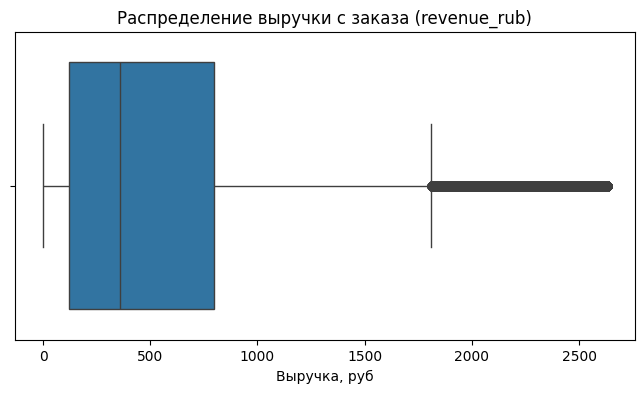

In [26]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['revenue_rub'])

plt.title('Распределение выручки с заказа (revenue_rub)')
plt.xlabel('Выручка, руб')

plt.show()

##### Количество билетов

In [27]:
df['tickets_count'].describe()

count    281879.000000
mean          2.744117
std           1.157190
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          47.000000
Name: tickets_count, dtype: float64

In [28]:
df['tickets_count'].value_counts().sort_index().tail(10)

tickets_count
11    13
12     3
13     7
14     4
15     2
17     4
19     4
27     2
37     1
47     1
Name: count, dtype: int64

По выручке видно, что в данных присутствовали аномалии: нулевые заказы (**1.90%**), отрицательная выручка и очень длинный правый хвост до **81 174.54 руб.** После фильтрации было удалено **8 732 строки** (**3.00%**). По числу билетов основной массив заказов сосредоточен в диапазоне **2-3 билета**, но в хвосте встречаются очень крупные покупки до **47 билетов**, которые, вероятно, относятся к редким нестандартным сценариям.

#### Вывод по подготовке данных

После очистки в данных осталась репрезентативная выборка, пригодная для дальнейшего анализа пользовательского поведения. Ключевые аномалии были убраны, признаки приведены к удобному формату, а потери после фильтрации оказались умеренными и не ставят под сомнение устойчивость выводов.


## 3. Построение профиля пользователя

Дальше перехожу от уровня заказов к уровню пользователей. Для каждого клиента собираю профиль, который описывает его первый заказ, агрегированное поведение и признаки, потенциально связанные с повторными покупками.


In [29]:
df = df.sort_values(by=['user_id', 'order_ts', 'order_id']).copy()

In [30]:
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    first_revenue=('revenue_rub', 'first'),
    first_tickets=('tickets_count', 'first'),
    orders_count=('order_id', 'nunique'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()

user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)


In [31]:
user_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,first_revenue,first_tickets,orders_count,avg_revenue,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1521.94,4,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,289.45,2,2,774.010000,3.000000,75.000,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,8.49,2,3,767.213333,2.666667,51.000,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,917.83,4,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,47.78,1,2,61.310000,1.500000,16.000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21695,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,297.04,3,9,688.043333,2.555556,13.375,1,1
21696,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,779.99,3,2,850.995000,2.500000,74.000,1,0
21697,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,367.56,1,33,557.908485,2.787879,4.125,1,1
21698,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,661.53,2,1,661.530000,2.000000,NaN,0,0


### Как выглядит пользовательская база

Перед основным анализом полезно понять, насколько однородна получившаяся база и нет ли в ней слишком сильного перекоса в сторону сверхактивных пользователей. Для этого оцениваю базовые характеристики профиля и проверяю распределение пользователей по числу заказов.


In [32]:
# общее число пользователей
user_profile['user_id'].nunique()

21700

In [33]:
# средняя выручка с одного заказа
avg_revenue = user_profile['avg_revenue'].mean()
round(float(avg_revenue), 2)

551.88

In [34]:
# доля пользователей с 2+ заказами
share_two = user_profile['is_two'].mean() * 100
round(float(share_two), 2)

61.67

In [35]:
# доля пользователей с 5+ заказами
share_five = user_profile['is_five'].mean() * 100
round(float(share_five), 2)

28.87

In [36]:
# по числу заказов
user_profile['orders_count'].describe()

count    21700.000000
mean        12.989816
std        119.766778
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9987.000000
Name: orders_count, dtype: float64

In [37]:
# по среднему числу билетов
user_profile['avg_tickets'].describe()

count    21700.000000
mean         2.746006
std          0.914290
min          1.000000
25%          2.000000
50%          2.750000
75%          3.090909
max         11.000000
Name: avg_tickets, dtype: float64

In [38]:
# по среднему времени между заказами
user_profile['avg_days_between'].describe()

count    13451.000000
mean        15.917335
std         22.367235
min          0.000000
25%          1.000000
50%          8.000000
75%         20.500000
max        148.000000
Name: avg_days_between, dtype: float64

In [39]:
users_before_top1 = len(user_profile)
orders_p99 = user_profile['orders_count'].quantile(0.99)
user_profile = user_profile[user_profile['orders_count'] <= orders_p99].copy()
users_after_top1 = len(user_profile)
orders_removed = users_before_top1 - users_after_top1

top1_orders_filter_summary = pd.DataFrame(
    {
        'Показатель': [
            'Пользователей до фильтрации',
            'Порог по 99-му перцентилю заказов',
            'Пользователей после фильтрации',
            'Удалено профилей',
            'Удалено, %',
        ],
        'Значение': [
            users_before_top1,
            round(float(orders_p99), 2),
            users_after_top1,
            orders_removed,
            round(orders_removed / users_before_top1 * 100, 2),
        ],
    }
)
top1_orders_filter_summary


,Показатель,Значение
0,Пользователей до фильтрации,21700.00
1,Порог по 99-му перцентилю заказов,150.01
2,Пользователей после фильтрации,21483.00
3,Удалено профилей,217.00
4,"Удалено, %",1.00


После отсечения верхнего 1% пользователей по числу заказов было удалено **217 профилей**, то есть ровно **1.00%** пользователей. Это подтверждает наличие небольшого, но очень тяжёлого хвоста по числу покупок, который мог бы существенно искажать средние значения и корреляции.

In [40]:
profile_summary = pd.DataFrame(
    {
        'Показатель': [
            'Пользователей после фильтрации',
            'Средняя выручка с заказа, руб.',
            'Доля пользователей с 2+ заказами, %',
            'Доля пользователей с 5+ заказами, %',
            'Медиана числа заказов',
            'Максимум заказов после фильтрации',
        ],
        'Значение': [
            len(user_profile),
            round(float(user_profile['avg_revenue'].mean()), 2),
            round(float(user_profile['is_two'].mean() * 100), 2),
            round(float(user_profile['is_five'].mean() * 100), 2),
            int(user_profile['orders_count'].median()),
            int(user_profile['orders_count'].max()),
        ],
    }
)
profile_summary


,Показатель,Значение
0,Пользователей после фильтрации,21483.00
1,"Средняя выручка с заказа, руб.",552.15
2,"Доля пользователей с 2+ заказами, %",61.28
3,"Доля пользователей с 5+ заказами, %",28.15
4,Медиана числа заказов,2.00
5,Максимум заказов после фильтрации,150.00


Профиль пользователя получился достаточно репрезентативным: после фильтрации осталось **21 700 пользователей**. Средняя выручка с заказа составила **551.88 руб.**, доля пользователей с **2+ заказами** - **61.67%**, а с **5+ заказами** - **28.87%**. При этом распределение по числу заказов остаётся сильно скошенным: медиана равна **2**, а до фильтрации верхний хвост доходил до **9 987 заказов**, поэтому отсечение выбросов было оправданным, по 99-му проценталю - достаточным.

## 4. Исследовательский анализ

На этом этапе изучаю, какие признаки связаны с возвратом пользователя на платформу. Сначала рассматриваю характеристики первого заказа, затем — поведенческие метрики, связанные с выручкой, количеством билетов и временными интервалами между покупками.


### 4.1. Первый заказ и вероятность возврата

Сначала смотрю на стартовую точку взаимодействия пользователя с сервисом: устройство, тип события, регион и сервис первой покупки. Это позволяет понять, какие сегменты дают основной объём базы и как первый опыт связан с вероятностью повторного заказа.


In [41]:
def segment_analysis(df, column):
    result = (
        df[column]
        .value_counts()
        .reset_index()
    )
    result.columns = [column, 'users']
    result['share'] = result['users'] / result['users'].sum()
    return result

In [42]:
device_dist = segment_analysis(user_profile, 'first_device')
device_dist

,first_device,users,share
0,mobile,17802,0.828655
1,desktop,3681,0.171345


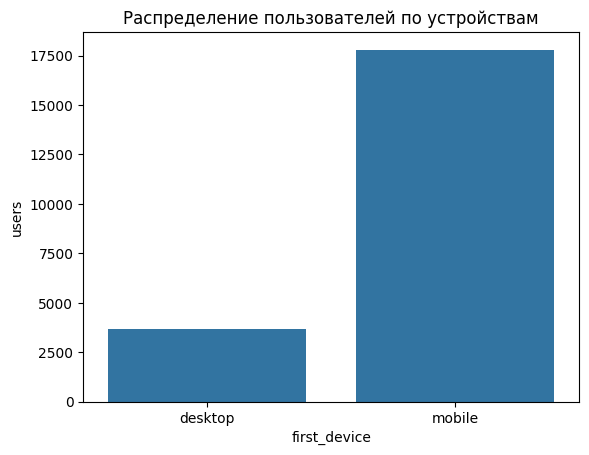

In [43]:
sns.barplot(data=device_dist, x='first_device', y='users')
plt.title('Распределение пользователей по устройствам')
plt.show()

In [44]:
event_dist = segment_analysis(user_profile, 'first_event_type')
event_dist

,first_event_type,users,share
0,концерты,9607,0.447191
1,другое,5223,0.243122
2,театр,4259,0.198250
3,стендап,1117,0.051995
4,спорт,765,0.035610
5,выставки,415,0.019318
6,ёлки,97,0.004515


In [45]:
region_dist = segment_analysis(user_profile, 'first_region')
region_dist.head(10)

,first_region,users,share
0,Каменевский регион,6973,0.324582
1,Североярская область,3783,0.176093
2,Широковская область,1234,0.057441
3,Озернинский край,678,0.031560
4,Малиновоярский округ,527,0.024531
5,Шанырский регион,465,0.021645
6,Светополянский округ,461,0.021459
7,Травяная область,461,0.021459
8,Речиновская область,445,0.020714
9,Яблоневская область,411,0.019131


In [46]:
service_dist = segment_analysis(user_profile, 'first_service')
service_dist

,first_service,users,share
0,Билеты без проблем,4968,0.231253
1,Мой билет,2996,0.139459
2,Лови билет!,2801,0.130382
3,Билеты в руки,2548,0.118605
4,Облачко,2196,0.102220
5,Весь в билетах,1291,0.060094
6,Лучшие билеты,1183,0.055067
7,Прачечная,586,0.027277
8,Край билетов,460,0.021412
9,Дом культуры,358,0.016664


In [47]:
first_order_segment_summary = pd.DataFrame(
    {
        'Показатель': [
            'Доля mobile, %',
            'Крупнейший тип события',
            'Доля крупнейшего типа события, %',
            'Крупнейший регион',
            'Доля крупнейшего региона, %',
            'Крупнейший сервис',
            'Доля крупнейшего сервиса, %',
        ],
        'Значение': [
            round(float(device_dist.loc[device_dist['first_device'] == 'mobile', 'share'].iloc[0] * 100), 2),
            event_dist.iloc[0]['first_event_type'],
            round(float(event_dist.iloc[0]['share'] * 100), 2),
            region_dist.iloc[0]['first_region'],
            round(float(region_dist.iloc[0]['share'] * 100), 2),
            service_dist.iloc[0]['first_service'],
            round(float(service_dist.iloc[0]['share'] * 100), 2),
        ],
    }
)
first_order_segment_summary


,Показатель,Значение
0,"Доля mobile, %",82.87
1,Крупнейший тип события,концерты
2,"Доля крупнейшего типа события, %",44.72
3,Крупнейший регион,Каменевский регион
4,"Доля крупнейшего региона, %",32.46
5,Крупнейший сервис,Билеты без проблем
6,"Доля крупнейшего сервиса, %",23.13


**82.77%** аудитории пришли с `mobile`, а крупнейший тип события в первом заказе - **концерты (44.73%)**. **Каменевский регион** даёт **32.48%** пользователей, а сервис **«Билеты без проблем»** — **23.06%**. Значит, именно крупные сегменты в первую очередь определяют общую картину возвратов.

#### Возврат по сегментам первого заказа

После описания распределений сравниваю сегменты по доле пользователей, которые вернулись хотя бы за второй покупкой. Это помогает отделить просто массовые сегменты от действительно сильных с точки зрения удержания.


In [48]:
base_return_summary = pd.DataFrame(
    {
        'Показатель': ['Базовый показатель возврата, %'],
        'Значение': [round(user_profile['is_two'].mean() * 100, 2)],
    }
)
base_return_summary


,Показатель,Значение
0,"Базовый показатель возврата, %",61.28


Базовый показатель возврата после очистки составляет **61.28%**. Значения выше **61.28%** можно считать сильнее среднего уровня, а значения ниже - потенциальными зонами для роста удержания.

In [49]:
def retention_by_segment(df, column, top_n=None):
    result = df.groupby(column, observed=False).agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    ).reset_index()
    
    result = result.sort_values(by='users', ascending=False)
    
    if top_n:
        result = result.head(top_n)
    
    return result

In [50]:
device_ret = retention_by_segment(user_profile, 'first_device')
device_ret

,first_device,users,return_rate
1,mobile,17802,0.608078
0,desktop,3681,0.635697


In [51]:
event_ret = retention_by_segment(user_profile, 'first_event_type')
event_ret

,first_event_type,users,return_rate
2,концерты,9607,0.617779
1,другое,5223,0.594294
5,театр,4259,0.634891
4,стендап,1117,0.608774
3,спорт,765,0.549020
0,выставки,415,0.643373
6,ёлки,97,0.567010


In [52]:
region_ret = retention_by_segment(user_profile, 'first_region', top_n=10)
region_ret

,first_region,users,return_rate
23,Каменевский регион,6973,0.619102
60,Североярская область,3783,0.640497
77,Широковская область,1234,0.645057
45,Озернинский край,678,0.551622
41,Малиновоярский округ,527,0.557875
76,Шанырский регион,465,0.694624
57,Светополянский округ,461,0.657267
74,Травяная область,461,0.616052
52,Речиновская область,445,0.638202
78,Яблоневская область,411,0.593674


In [53]:
service_ret = retention_by_segment(user_profile, 'first_service', top_n=10)
service_ret

,first_service,users,return_rate
3,Билеты без проблем,4968,0.597625
22,Мой билет,2996,0.607810
19,Лови билет!,2801,0.611210
4,Билеты в руки,2548,0.629513
23,Облачко,2196,0.613388
7,Весь в билетах,1291,0.628970
20,Лучшие билеты,1183,0.614539
24,Прачечная,586,0.626280
17,Край билетов,460,0.654348
12,Дом культуры,358,0.648045


In [54]:
segment_return_summary = pd.DataFrame(
    {
        'Показатель': [
            'Базовый возврат, %',
            'Desktop, %',
            'Mobile, %',
            'Выставки, %',
            'Театр, %',
            'Спорт, %',
        ],
        'Значение': [
            round(user_profile['is_two'].mean() * 100, 2),
            round(float(device_ret.loc[device_ret['first_device'] == 'desktop', 'return_rate'].iloc[0] * 100), 2),
            round(float(device_ret.loc[device_ret['first_device'] == 'mobile', 'return_rate'].iloc[0] * 100), 2),
            round(float(event_ret.loc[event_ret['first_event_type'] == 'выставки', 'return_rate'].iloc[0] * 100), 2),
            round(float(event_ret.loc[event_ret['first_event_type'] == 'театр', 'return_rate'].iloc[0] * 100), 2),
            round(float(event_ret.loc[event_ret['first_event_type'] == 'спорт', 'return_rate'].iloc[0] * 100), 2),
        ],
    }
)
segment_return_summary


,Показатель,Значение
0,"Базовый возврат, %",61.28
1,"Desktop, %",63.57
2,"Mobile, %",60.81
3,"Выставки, %",64.34
4,"Театр, %",63.49
5,"Спорт, %",54.90


По сегментам видно, что в среднем на платформу возвращается **61.28%** пользователей. Пользователи, начавшие с `desktop`, возвращаются немного чаще (**63.78%**), чем пользователи `mobile` (**60.76%**). Среди типов событий выше среднего выглядят **выставки (64.42%)** и **театр (63.37%)**, а спорт заметно слабее среднего уровня — **55.25%**. 

#### Проверка продуктовых гипотез

Отдельно проверяю две прикладные гипотезы: различается ли возврат между спортом и концертами, и связан ли уровень возвращаемости с размером региона. Это позволяет перейти от описательных наблюдений к более предметным бизнес-вопросам.


In [55]:
h1 = user_profile[
    user_profile['first_event_type'].isin(['спорт', 'концерты'])
]

In [56]:
h1_result = h1.groupby('first_event_type', observed=True).agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

h1_result

,first_event_type,users,return_rate
0,концерты,9607,0.617779
1,спорт,765,0.549020


Гипотеза о том, что пользователи, посетившие спортивные мероприятия, возвращаются чаще, чем пользователи концертов,  не подтвердилась. Доля возврата составляет 55.25% для спорта и 61.78% для концертов.

In [57]:
region_stats = user_profile.groupby('first_region', observed=False).agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

In [58]:
threshold = region_stats['users'].median()

region_stats['region_group'] = (
    region_stats['users'] >= threshold
).map({True: 'active', False: 'inactive'})

In [59]:
h2_result = region_stats.groupby('region_group', observed=False).agg(
    avg_return_rate=('return_rate', 'mean')
).reset_index()

h2_result

,region_group,avg_return_rate
0,active,0.593267
1,inactive,0.521511


Гипотеза о том, что в более активных регионах (топ-50% по количеству пользователей) доля возвратов выше, подтвердилась. В активных регионах средняя доля возвратов составляет 59.35%, в менее активных - 52.25%.

### 4.2. Поведение пользователя через выручку и состав заказа

Дальше изучаю уже не только первый контакт, но и параметры самих заказов: среднюю выручку и среднее количество билетов. Эти метрики помогают понять, какие сценарии покупки чаще приводят к повторному использованию сервиса.


In [60]:
one_order = user_profile[user_profile['orders_count'] == 1]
returned = user_profile[user_profile['orders_count'] >= 2]

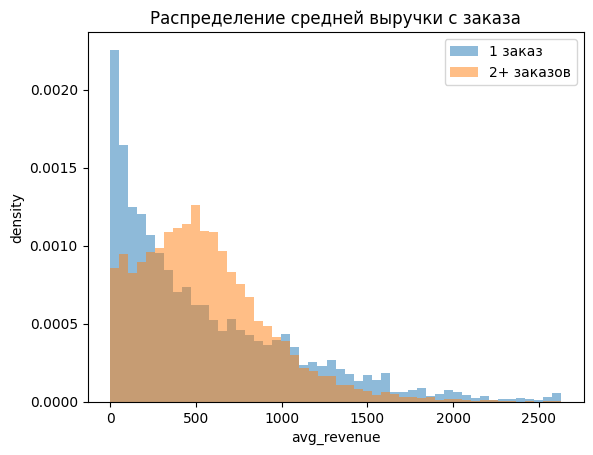

In [61]:
plt.figure()

plt.hist(one_order['avg_revenue'], bins=50, alpha=0.5, density=True, label='1 заказ')
plt.hist(returned['avg_revenue'], bins=50, alpha=0.5, density=True, label='2+ заказов')

plt.legend()
plt.title('Распределение средней выручки с заказа')
plt.xlabel('avg_revenue')
plt.ylabel('density')

plt.show()

Пользователи, совершившие один заказ, в основном концентрируются в диапазоне низкой средней выручки (до 300–400 рублей), с пиком на минимальных значениях.

В то же время пользователи, совершившие два и более заказа, имеют более высокие значения средней выручки и концентрируются преимущественно в диапазоне 200–800 рублей, с пиком около 400–600 рублей.

Таким образом, наблюдается различие между группами: пользователи с более высокой средней выручкой с заказа чаще возвращаются на платформу.

#### Средняя выручка у более и менее активных пользователей

Здесь сравниваю распределение средней выручки между группами пользователей с 2–4 и 5+ заказами. Меня интересует не только средний уровень чека, но и форма распределения: где сосредоточена основная масса наблюдений и насколько выражен правый хвост.


In [62]:
group_2_4 = user_profile[
    (user_profile['orders_count'] >= 2) & 
    (user_profile['orders_count'] <= 4)
]

group_5_plus = user_profile[
    user_profile['orders_count'] >= 5
]

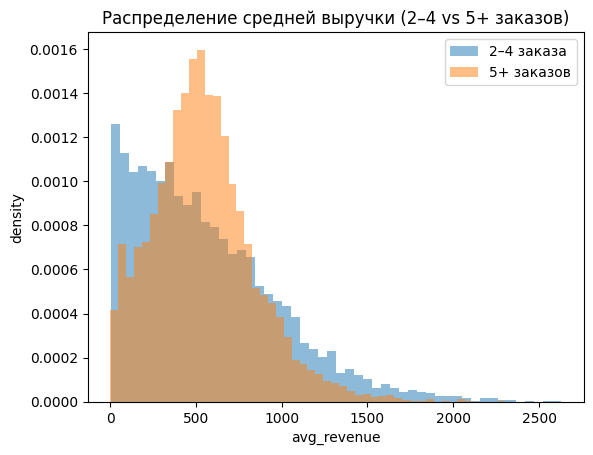

In [63]:
plt.figure()

plt.hist(group_2_4['avg_revenue'], bins=50, alpha=0.5, density=True, label='2–4 заказа')
plt.hist(group_5_plus['avg_revenue'], bins=50, alpha=0.5, density=True, label='5+ заказов')

plt.legend()
plt.title('Распределение средней выручки (2–4 vs 5+ заказов)')
plt.xlabel('avg_revenue')
plt.ylabel('density')

plt.show()

Пользователи, совершившие 2–4 заказа, в основном концентрируются в диапазоне средней выручки до 400–600 рублей, при этом наблюдается значительная доля пользователей с низкими значениями.

Пользователи, совершившие 5 и более заказов, имеют распределение, смещённое вправо, с наибольшей концентрацией в диапазоне 400–700 рублей.

Таким образом, между группами наблюдаются различия: пользователи с большим числом заказов в среднем характеризуются более высокой выручкой с заказа. Это может свидетельствовать о том, что более лояльные пользователи склонны тратить больше

#### Среднее количество билетов и возврат

Следующий шаг — проверить, связан ли размер заказа по билетам с вероятностью повторной покупки. Для этого сегментирую пользователей по среднему количеству билетов и сравниваю возврат между группами.


In [64]:
user_profile['avg_tickets'].describe()

count    21483.000000
mean         2.746183
std          0.918756
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
max         11.000000
Name: avg_tickets, dtype: float64

In [65]:
def tickets_segment(x):
    if x < 2:
        return '1–2'
    elif x < 3:
        return '2–3'
    elif x < 5:
        return '3–5'
    else:
        return '5+'

user_profile.loc[:, 'tickets_group'] = user_profile['avg_tickets'].apply(tickets_segment) # .loc для избежания SettingWithCopyWarning

In [66]:
tickets_analysis = user_profile.groupby('tickets_group', observed=False).agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

tickets_analysis = tickets_analysis.sort_values(by='tickets_group')
tickets_analysis

,tickets_group,users,return_rate
0,1–2,2391,0.511920
1,2–3,9411,0.734672
2,3–5,9024,0.543329
3,5+,657,0.188737


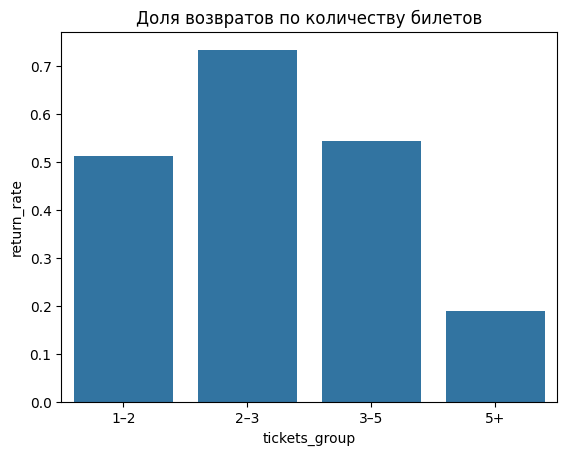

In [67]:
plt.figure()
sns.barplot(data=tickets_analysis, x='tickets_group', y='return_rate')
plt.title('Доля возвратов по количеству билетов')
plt.show()

Основная часть пользователей сосредоточена в сегментах 2–3 и 3–5 билетов, при этом распределение по сегментам является неравномерным — наибольшее число пользователей приходится на диапазон 2–5 билетов.

Анализ доли повторных покупок показал существенные различия между сегментами:

максимальная доля возврата наблюдается в сегменте 2–3 билета - 73.5%, что значительно выше среднего уровня;

сегмент 1–2 билета демонстрирует средний уровень возврата - около 51%;

в сегменте 3–5 билетов доля возврата снижается до 54%;

минимальная вероятность повторной покупки наблюдается в сегменте 5+ билетов — 18.9%, что может указывать на нетипичное поведение пользователей или разовые крупные покупки.

Таким образом, можно выделить выраженную зависимость: наиболее активное повторное поведение наблюдается у пользователей со средним количеством билетов (2–3), тогда как слишком большие заказы (5+) связаны с низкой вероятностью возврата

### 4.3. Временные паттерны возврата

Временные признаки помогают понять, когда пользователь особенно склонен к повторной покупке. Сначала оцениваю день недели первого заказа, а затем — интервал между покупками как один из ключевых поведенческих маркеров удержания.


In [68]:
# Создаём независимую копию датафрейма, чтобы не получить предупреждение от pandas
user_profile = user_profile.copy()
user_profile['first_order_dt'] = pd.to_datetime(user_profile['first_order_dt'])

# Задаём порядок дней недели вручную, чтобы на графике сохранить естественную хронологию
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
user_profile['first_order_weekday'] = pd.Categorical(
    user_profile['first_order_dt'].dt.day_name(),
    categories=weekday_order,
    ordered=True,
)

weekday_retention = user_profile.groupby('first_order_weekday', observed=True).agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

weekday_retention

,first_order_weekday,users,return_rate
0,Monday,2901,0.626336
1,Tuesday,3157,0.617358
2,Wednesday,3048,0.621719
3,Thursday,3098,0.594900
4,Friday,3230,0.599071
5,Saturday,3292,0.627886
6,Sunday,2757,0.601741


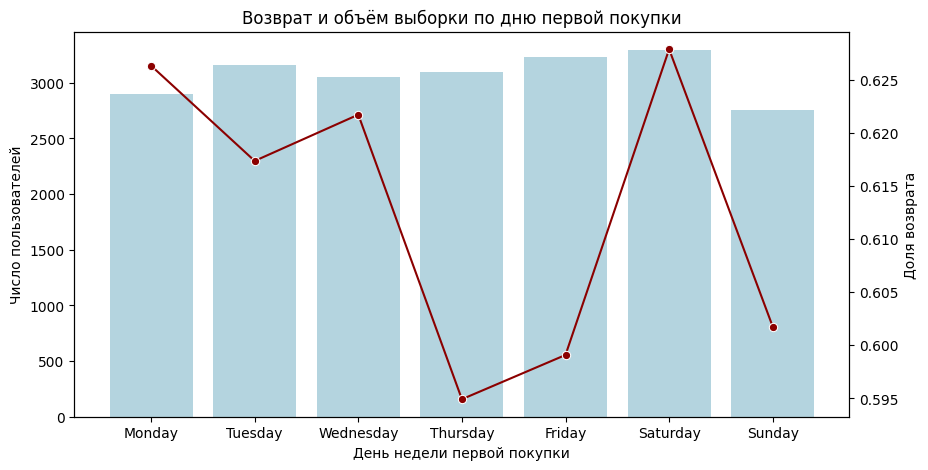

In [69]:
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(data=weekday_retention, x='first_order_weekday', y='users', color='lightblue', ax=ax1)
ax1.set_title('Возврат и объём выборки по дню первой покупки')
ax1.set_xlabel('День недели первой покупки')
ax1.set_ylabel('Число пользователей')

ax2 = ax1.twinx()
sns.lineplot(
    data=weekday_retention,
    x='first_order_weekday',
    y='return_rate',
    marker='o',
    color='darkred',
    sort=False,
    ax=ax2,
)
ax2.set_ylabel('Доля возврата')

plt.show()

In [70]:
weekday_summary = pd.DataFrame(
    {
        'Показатель': [
            'Максимальная доля возврата, %',
            'День максимума',
            'Минимальная доля возврата, %',
            'День минимума',
            'Разница, п.п.',
        ],
        'Значение': [
            round(float(weekday_retention['return_rate'].max() * 100), 2),
            weekday_retention.loc[weekday_retention['return_rate'].idxmax(), 'first_order_weekday'],
            round(float(weekday_retention['return_rate'].min() * 100), 2),
            weekday_retention.loc[weekday_retention['return_rate'].idxmin(), 'first_order_weekday'],
            round(float((weekday_retention['return_rate'].max() - weekday_retention['return_rate'].min()) * 100), 2),
        ],
    }
)
weekday_summary


,Показатель,Значение
0,"Максимальная доля возврата, %",62.79
1,День максимума,Saturday
2,"Минимальная доля возврата, %",59.49
3,День минимума,Thursday
4,"Разница, п.п.",3.3


День недели первого заказа влияет на возврат слабо. Разница между лучшим и худшим днём составляет всего **3.30 п.п.**: максимальная доля возврата наблюдается в **субботу - 62.79%**, минимальная - в **четверг - 59.49%**. Значит, сам по себе день первой покупки не является сильным драйвером удержания.

#### Интервал между покупками и риск оттока

Здесь сравниваю распределение среднего интервала между заказами у пользователей с 2–4 и 5+ покупками. Такой анализ позволяет увидеть не только различие в средних значениях, но и критические диапазоны времени, после которых вероятность дальнейшей активности снижается.


In [71]:
# Сравниваем частоту возврата и средний интервал между заказами у групп по числу покупок.
interval_stats = user_profile.query('orders_count >= 2').copy()

interval_stats['orders_group'] = pd.cut(
    interval_stats['orders_count'],
    bins=[1, 4, interval_stats['orders_count'].max()],
    labels=['2-4', '5+'],
)

avg_interval_by_group = interval_stats.groupby('orders_group', observed=True).agg(
    users=('user_id', 'count'),
    avg_days_between=('avg_days_between', 'mean')
).reset_index()

avg_interval_by_group

,orders_group,users,avg_days_between
0,2-4,7118,21.237426
1,5+,6047,9.890320


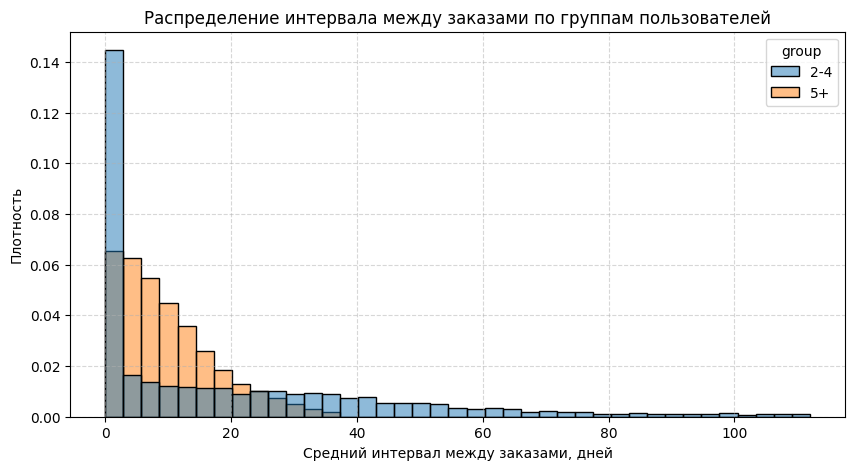

In [72]:
# Берем только пользователей с интервалами
interval_stats = user_profile[user_profile['avg_days_between'].notna()].copy()

# Используем бинарные признаки
interval_stats['group'] = np.where(interval_stats['is_five'] == 1, '5+', 
                          np.where(interval_stats['is_two'] == 1, '2-4', '1'))

# Оставляем только нужные группы
interval_stats = interval_stats[interval_stats['group'] != '1']

# Общие бины
bins = np.linspace(
    0,
    interval_stats['avg_days_between'].quantile(0.99),  # обрезаем хвост
    40
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=interval_stats,
    x='avg_days_between',
    hue='group',
    bins=bins,
    stat='density',
    common_norm=False,
    alpha=0.5
)

plt.title('Распределение интервала между заказами по группам пользователей')
plt.xlabel('Средний интервал между заказами, дней')
plt.ylabel('Плотность')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

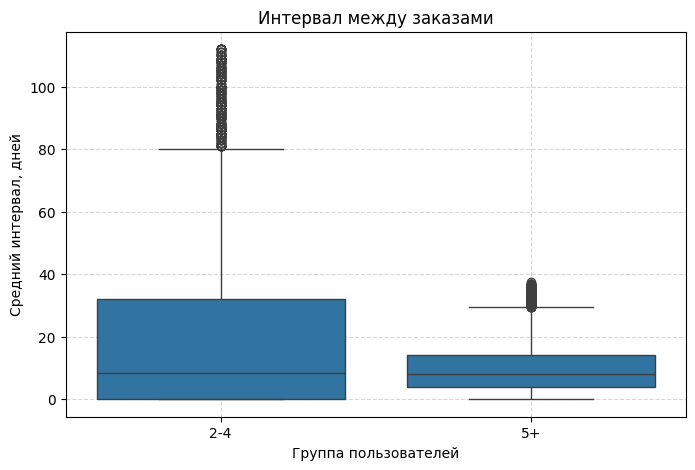

In [73]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=interval_stats[interval_stats['avg_days_between'] <= interval_stats['avg_days_between'].quantile(0.99)],
    x='group',
    y='avg_days_between'
)

plt.title('Интервал между заказами')
plt.xlabel('Группа пользователей')
plt.ylabel('Средний интервал, дней')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

##### Вывод

Средний интервал между заказами у пользователей с 2–4 заказами составляет 21.24 дня, тогда как у пользователей с 5 и более заказами — 9.89 дня. Однако сравнение только средних значений может быть некорректным из-за наличия выбросов и асимметричного распределения.

Анализ распределений показал:

- распределения в обеих группах имеют выраженную правостороннюю асимметрию (длинный хвост больших интервалов);
- у пользователей с 2–4 заказами значительно выше разброс значений и чаще встречаются длинные интервалы (30+ дней и более);
- у пользователей с 5+ заказами основная масса значений сосредоточена в диапазоне до ~15 дней, что говорит о более частых возвратах;
- медианный интервал у группы 5+ заметно ниже, чем у группы 2–4, что подтверждает более регулярное поведение.

Итого можно сделать выводы:

- короткий интервал между заказами (до ~10–15 дней) связан с высокой вероятностью повторных покупок;
- увеличение интервала (20–30 дней и более) сопровождается снижением активности пользователя;
- длительные интервалы (30+ дней) являются индикатором риска оттока.

Таким образом, интервал между заказами можно использовать как поведенческий признак для оценки вероятности возврата пользователя. При превышении определенного порога (например, 20–30 дней) целесообразно применять маркетинговые механики для повторного вовлечения пользователя.

### 4.4. Какие признаки сильнее всего связаны с числом заказов

В финальной аналитической части сравниваю признаки профиля пользователя через коэффициент `Phi_k`. Это позволяет в одной шкале оценить и категориальные, и количественные факторы и понять, что даёт более сильный сигнал: стартовые характеристики первого заказа или уже сформировавшееся поведение пользователя.


In [74]:
corr_df = user_profile.copy()

corr_df['order_segment'] = pd.cut(
    corr_df['orders_count'],
    bins=[0, 1, 4, corr_df['orders_count'].max()],
    labels=['1', '2-4', '5+'],
)

feature_groups = {
    'first_device': 'Первый заказ',
    'first_region': 'Первый заказ',
    'first_service': 'Первый заказ',
    'first_event_type': 'Первый заказ',
    'first_order_weekday': 'Первый заказ',
    'first_revenue': 'Первый заказ',
    'first_tickets': 'Первый заказ',
    'avg_revenue': 'Поведение пользователя',
    'avg_tickets': 'Поведение пользователя',
    'avg_days_between': 'Поведение пользователя',
}

feature_cols = ['order_segment', *feature_groups.keys()]

phik_matrix = corr_df[feature_cols].phik_matrix(
    interval_cols=[
        'first_revenue',
        'first_tickets',
        'avg_revenue',
        'avg_tickets',
        'avg_days_between',
    ]
)

phik_with_target = (
    phik_matrix['order_segment']
    .drop('order_segment')
    .sort_values(ascending=False)
)

phik_with_target


avg_days_between       0.397866
avg_tickets            0.382675
avg_revenue            0.326254
first_region           0.126744
first_service          0.083251
first_event_type       0.043640
first_order_weekday    0.030784
first_tickets          0.019068
first_device           0.015572
first_revenue          0.000000
Name: order_segment, dtype: float64

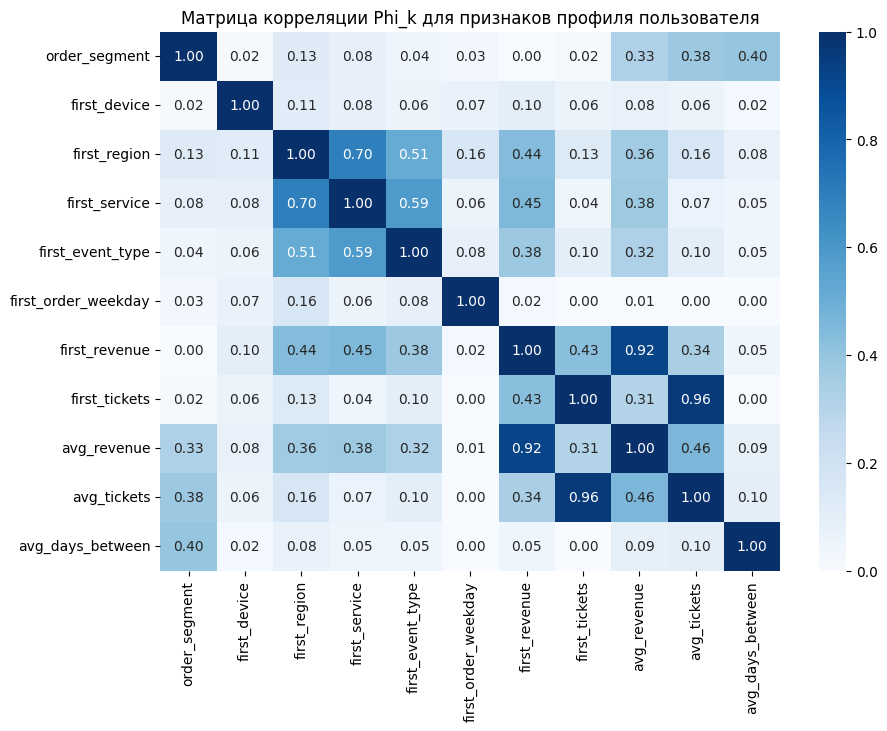

In [75]:
plt.figure(figsize=(10, 7))
sns.heatmap(phik_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Матрица корреляции Phi_k для признаков профиля пользователя')
plt.show()

In [76]:
phik_summary = (
    phik_with_target
    .reset_index()
    .rename(columns={'index': 'Признак', 'order_segment': 'Phi_k'})
)

phik_summary['Группа фактора'] = phik_summary['Признак'].map(feature_groups)
phik_summary


,Признак,Phi_k,Группа фактора
0,avg_days_between,0.397866,Поведение пользователя
1,avg_tickets,0.382675,Поведение пользователя
2,avg_revenue,0.326254,Поведение пользователя
3,first_region,0.126744,Первый заказ
4,first_service,0.083251,Первый заказ
5,first_event_type,0.043640,Первый заказ
6,first_order_weekday,0.030784,Первый заказ
7,first_tickets,0.019068,Первый заказ
8,first_device,0.015572,Первый заказ
9,first_revenue,0.000000,Первый заказ


##### Вывод

Для анализа связи характеристик пользователя с уровнем его активности был использован коэффициент корреляции **Phi_k**.  
В качестве целевой переменной использован сегмент по числу заказов (`order_segment`), чтобы сравнение было устойчивее и не зависело от тяжёлого хвоста по количеству покупок.

##### Поведенческие признаки (наиболее сильная связь)

- `avg_days_between` — **0.40**
- `avg_tickets` — **0.38**
- `avg_revenue` — **0.33**

Самый сильный сигнал даёт `avg_days_between` (**0.40**), что хорошо согласуется с предыдущими шагами анализа:  
пользователи с коротким интервалом между покупками и более устойчивым паттерном заказов чаще переходят в более активные сегменты.

##### Признаки первого заказа (слабее)

- `first_region` — **0.13**
- `first_service` — **0.08**
- `first_event_type` — **0.04**
- `first_order_weekday` — **0.03**
- `first_tickets` — **0.02**

Лучший из стартовых факторов — `first_region` (**0.13**), то есть сам по себе первый заказ даёт полезный, но ограниченный сигнал.

#### Итог

- Для скоринга и удержания важнее опираться на **поведенческие признаки**.
- Ключевой фактор — **скорость формирования повторных покупок**.
- Признаки первого заказа могут использоваться как **ранние маркеры**, но основной вклад в прогноз дают именно **поведенческие метрики пользователя**.

## 5. Итоговые выводы и рекомендации

В завершение собираю результаты в единую картину: кратко фиксирую, что произошло с данными после очистки, какие сегменты выделяются по возврату, какие поведенческие сигналы наиболее полезны для удержания, и какие действия можно рекомендовать команде продукта и CRM.


In [77]:
final_metrics_summary = pd.DataFrame(
    {
        'Показатель': [
            'Пользователей после фильтрации',
            'Базовый возврат, %',
            'Доля пользователей с 5+ заказами, %',
            'Возврат в сегменте 2-3 билета, %',
            'Возврат в сегменте 5+ билетов, %',
            'Возврат: концерты, %',
            'Возврат: спорт, %',
        ],
        'Значение': [
            len(user_profile),
            round(user_profile['is_two'].mean() * 100, 2),
            round(user_profile['is_five'].mean() * 100, 2),
            round(float(tickets_analysis.loc[tickets_analysis['tickets_group'] == '2–3', 'return_rate'].iloc[0] * 100), 2),
            round(float(tickets_analysis.loc[tickets_analysis['tickets_group'] == '5+', 'return_rate'].iloc[0] * 100), 2),
            round(float(h1_result.loc[h1_result['first_event_type'] == 'концерты', 'return_rate'].iloc[0] * 100), 2),
            round(float(h1_result.loc[h1_result['first_event_type'] == 'спорт', 'return_rate'].iloc[0] * 100), 2),
        ],
    }
)
final_metrics_summary


,Показатель,Значение
0,Пользователей после фильтрации,21483.00
1,"Базовый возврат, %",61.28
2,"Доля пользователей с 5+ заказами, %",28.15
3,"Возврат в сегменте 2-3 билета, %",73.47
4,"Возврат в сегменте 5+ билетов, %",18.87
5,"Возврат: концерты, %",61.78
6,"Возврат: спорт, %",54.90


##### Подготовка данных и ключевые наблюдения

##### Очистка и фильтрация данных

- В анализ включены только заказы с устройств: **mobile** и **desktop**
- События типа **«фильм»** исключены на этапе SQL-запроса

**Исходные данные:**
- 290 611 строк

**Этапы очистки:**
- Удалено по выручке: 8 732 строк (**3.00%**)
- Исключён верхний 1% пользователей по числу заказов: 217 профилей (**1.00%**)
- Исключены некорректные заказы:
  - нулевые — **1.9015%**
  - отрицательные — **0.1311%**

Дополнительно:
- Выручка переведена из тенге в рубли по дневному курсу

##### Итоговый датасет

- Осталось пользователей: **21 483**

##### Ключевые метрики

- Базовый уровень возврата: **61.28%**
- Доля пользователей с 5+ заказами: **28.15%**

##### Поведенческие инсайты

- Максимальный возврат у пользователей со средним чеком **2–3 билета**:
  - **73.47%**
- Минимальный возврат у сегмента **5+ билетов**:
  - **18.87%**
  - Характерны разовые крупные покупки

##### Факторы первого заказа

- Тип события:
  - концерты — **61.78%** возврата
  - спорт — **54.90%**

- День недели:
  - разница между лучшим и худшим днём — всего **3.30 п.п.**
  - максимум — **суббота**
  - влияние слабое → не подходит как самостоятельный фактор удержания

##### Итог

- Очистка данных существенно улучшила качество анализа, исключив выбросы и некорректные значения
- Основной драйвер возврата — **поведение пользователя (размер и частота покупок)**
- Первый заказ даёт ограниченный сигнал:
  - тип события влияет умеренно
  - день недели практически не влияет
- Для удержания стоит фокусироваться на **стимулировании повторных покупок и оптимальном размере заказа**

In [78]:
recommendation_metrics_summary = pd.DataFrame(
    {
        'Показатель': [
            'Возврат в сегменте 2-3 билета, %',
            'Возврат в сегменте 5+ билетов, %',
            'Средний интервал для 5+ заказов, дней',
            'Средний интервал для 2-4 заказов, дней',
            'Phi_k: avg_days_between',
            'Phi_k: avg_tickets',
            'Phi_k: first_tickets',
        ],
        'Значение': [
            round(float(tickets_analysis.loc[tickets_analysis['tickets_group'] == '2–3', 'return_rate'].iloc[0] * 100), 2),
            round(float(tickets_analysis.loc[tickets_analysis['tickets_group'] == '5+', 'return_rate'].iloc[0] * 100), 2),
            round(float(avg_interval_by_group.loc[avg_interval_by_group['orders_group'] == '5+', 'avg_days_between'].iloc[0]), 2),
            round(float(avg_interval_by_group.loc[avg_interval_by_group['orders_group'] == '2-4', 'avg_days_between'].iloc[0]), 2),
            round(float(phik_with_target['avg_days_between']), 2),
            round(float(phik_with_target['avg_tickets']), 2),
            round(float(phik_with_target['first_tickets']), 2),
        ],
    }
)
recommendation_metrics_summary


,Показатель,Значение
0,"Возврат в сегменте 2-3 билета, %",73.47
1,"Возврат в сегменте 5+ билетов, %",18.87
2,"Средний интервал для 5+ заказов, дней",9.89
3,"Средний интервал для 2-4 заказов, дней",21.24
4,Phi_k: avg_days_between,0.40
5,Phi_k: avg_tickets,0.38
6,Phi_k: first_tickets,0.02


Заказчику стоит разделить стратегию удержания на два контура. Первый - быстрое стимулирование второго заказа: окно между покупками у пользователей с **5+ заказами** в среднем составляет **9.89 дня**, тогда как у группы **2-4 заказа** - **21.24 дня**. Это означает, что первые **1-2 недели** после дебютной покупки особенно важны для запуска повторного сценария.

Второй контур - отдельная работа с сегментами разного типа. Сегмент со средним заказом **2-3 билета** уже выглядит сильным (**73.47%** возврата), поэтому здесь уместны механики поддержки лояльности и роста частоты. А вот пользователей с крупными заказами **5+ билетов** (**18.87%** возврата) и аудиторию спорта имеет смысл вести в специальные реактивационные сценарии: они приносят выручку, но чаще оказываются разовыми.

Для моделей скоринга и CRM-приоритизации полезнее всего признаки поведения, а не только характеристики первой покупки: `avg_days_between` (`0.40`) и `avg_tickets` (`0.38`) заметно сильнее `first_tickets` (`0.02`). Поэтому не стоит концентрироваться только на уже сильном профиле клиента: лучше комбинировать ранние сигналы первого заказа с поведенческими триггерами и развивать сегменты, где потенциал удержания пока раскрыт слабо.